In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.robust.scale as srs
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from scipy.stats import kurtosis

In [7]:
df = yf.download('PGE.WA', start='2020-01-01', end='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [8]:
print(df.head())

Price       Close   High    Low   Open   Volume
Ticker     PGE.WA PGE.WA PGE.WA PGE.WA   PGE.WA
Date                                           
2020-01-01  7.960   7.96  7.960  7.960        0
2020-01-02  8.266   8.28  7.998  8.000  1231536
2020-01-03  8.150   8.24  8.060  8.240  1793506
2020-01-06  8.150   8.15  8.150  8.150        0
2020-01-07  7.930   8.22  7.930  8.196  1151834


In [9]:
close_prices = df['Close']['PGE.WA']

In [10]:
close_prices

Date
2020-01-01    7.960
2020-01-02    8.266
2020-01-03    8.150
2020-01-06    8.150
2020-01-07    7.930
              ...  
2025-12-19    8.570
2025-12-22    8.640
2025-12-23    8.640
2025-12-29    8.768
2025-12-30    8.804
Name: PGE.WA, Length: 1509, dtype: float64

In [11]:
log_returns = np.log(close_prices).diff()

In [12]:
print(log_returns.head())


Date
2020-01-01         NaN
2020-01-02    0.037722
2020-01-03   -0.014133
2020-01-06    0.000000
2020-01-07   -0.027365
Name: PGE.WA, dtype: float64


In [13]:
na_values = log_returns.isna().sum()
print(na_values)

1


In [14]:
log_returns = log_returns.dropna()

#### POSITION ESTIMATORS


In [15]:
def position_estimators(df):
    mean = df.mean()
    trim_mean = st.trim_mean(df, 0.1)
    median = df.median()
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    return mean, trim_mean, median, Q3, Q1

mean, trim_mean, median, Q3, Q1 = position_estimators(log_returns)

In [16]:
print(f'mean: {mean:.10f}\ntrim mean: {trim_mean:.5f}\nmedian: {median:.5f}\nquantile(0.75): {Q3:.5f}\nquantile(0.25): {Q1:.5f}')

mean: 0.0000668283
trim mean: -0.00053
median: -0.00089
quantile(0.75): 0.01509
quantile(0.25): -0.01587


#### INTERPRETATION
   1. **MEAN AND MEDIAN** - Mean vs. Median: The arithmetic mean is slightly positive `(0.000067)`, whereas the median is negative `(-0.000895)`. This discrepancy mathematically confirms the *positive skewness* **(right-skewed distribution)** we observed on the histogram.
   2. **TRIMMED MEAN** `(-0.0005)` - By stripping away the top 10% and bottom 10% of extreme returns, the trimmed mean evaluates only the core data. Its value (-0.000526) aligns much closer to the median. This robust metric proves that once the noise of extreme market  and panic is removed, the stock's fundamental central tendency leans slightly negative.

#### DISPERSION ESTIMATORS


In [17]:
def dispersion_estimators(df):
    std = df.std()
    iqr = df.quantile(0.75) - df.quantile(0.25)
    mad = srs.mad(df)
    s2 = np.var(df)
    s = np.sqrt(s2)
    return std, iqr, mad, s2, s

std, iqr, mad, s2, s = dispersion_estimators(log_returns)

In [18]:
print(std, iqr, mad, s2, s)

0.03001028506902713 0.030968205633949863 0.022917255118153797 0.0009000199836577446 0.030000333059113603


#### INTERPRETATION
   1. **STD**`(0.030)` - The daily standard deviation is approximately 3.00%. In traditional finance, this represents the average daily volatility. However, because standard deviation squares the distances from the mean, this metric is highly sensitive to the extreme outliers we identified earlier in the boxplot.
   2. **IQR** `(0.031)` - he IQR shows that the middle 50% of all daily returns fall within a 3.10% range. As a robust statistic, it confirms that the "core" trading days experience moderate fluctuations, ignoring the massive crashes or surges at the extremes.
   3. **MAD** `(0.022)` - MAD is a highly robust measure of dispersion, completely resistant to outliers. The fact that the MAD (2.29%) is notably lower than the Standard Deviation (3.00%) is a crucial finding. It mathematically confirms that extreme market shocks are artificially inflating the standard volatility metrics. The "typical" daily price movement is closer to 2.29%, while the remaining volatility comes from rare, extreme tail events.

### BOXPLOT

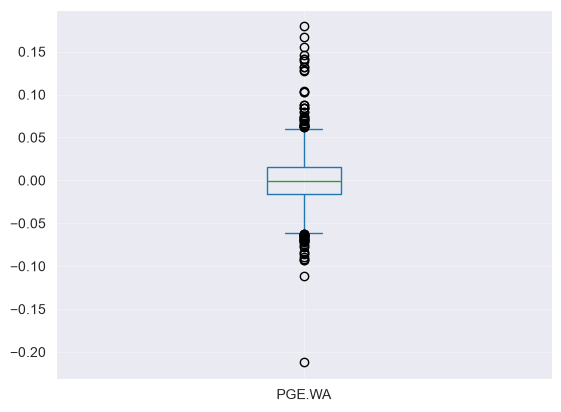

In [19]:
log_returns.plot.box()
plt.grid(
    alpha = 0.3
)

##### CONCLUSIONS
- the box, which contains the middle 50% of the data is extremaly narrow and tightly compressed around the zero line
- during the vast majority of trading sessions, the stocks price fluctuations are minimal
- the market is generally calm

### DATA DISTRIBUTION

In [20]:
n = len(log_returns)

k1 = int(np.ceil(5 * np.log10(n)))

k2 = int(np.ceil(1 + 3.322 * np.log10(n)))

print(k1,k2)

16 12


In [21]:
x = pd.cut(log_returns, 14)
x.value_counts()

PGE.WA
(-0.0164, 0.0116]     694
(0.0116, 0.0396]      352
(-0.0444, -0.0164]    275
(-0.0723, -0.0444]     74
(0.0396, 0.0675]       72
(0.0675, 0.0955]       15
(-0.1, -0.0723]        10
(0.123, 0.151]          8
(0.0955, 0.123]         3
(0.151, 0.179]          3
(-0.213, -0.184]        1
(-0.128, -0.1]          1
(-0.184, -0.156]        0
(-0.156, -0.128]        0
Name: count, dtype: int64

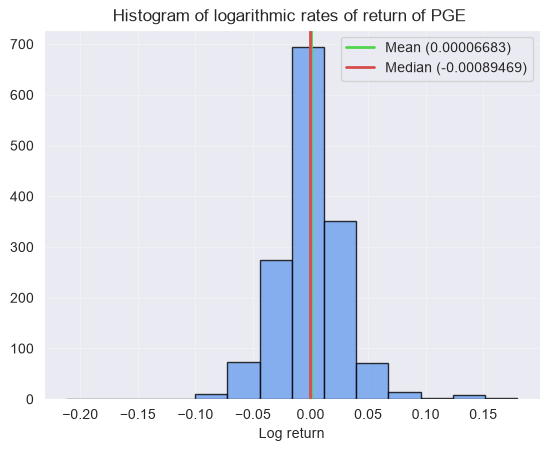

In [22]:
plt.hist(
    log_returns,
    bins = 14,
    alpha = 0.8,
    edgecolor = 'black',
    color = '#6CA0EF',
)

plt.axvline(
    mean,
    color='#4FD64D',
    linestyle='-',
    linewidth=2,
    label=f'Mean ({mean:.8f})'
)

plt.axvline(
    median,
    color='#D64D4D',
    linestyle='-',
    linewidth=2,
    label=f'Median ({median:.8f})'
)

plt.grid(
    alpha = 0.3
)

plt.title('Histogram of logarithmic rates of return of PGE ')
plt.xlabel('Log return')
plt.legend()
plt.show()


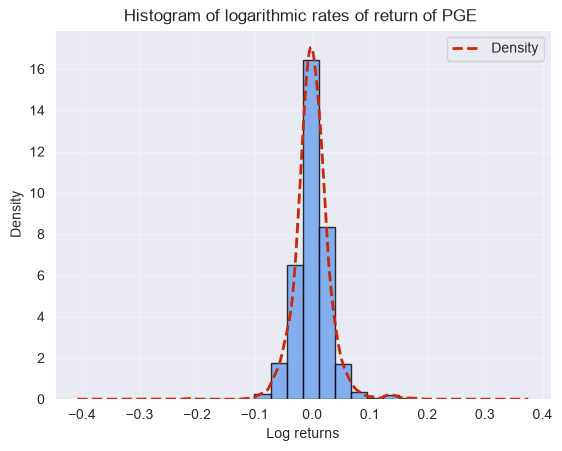

In [23]:
plt.hist(
    log_returns,
    bins = 14,
    density=True,
    alpha = 0.8,
    edgecolor = 'black',
    color = '#6CA0EF',
)

log_returns.plot.density(
    color = '#C82909',
    linestyle = '--',
    linewidth = 2,
    label = 'Density',
)

plt.grid(
    alpha = 0.3
)

plt.title('Histogram of logarithmic rates of return of PGE ')
plt.xlabel('Log returns')
plt.legend()
plt.show()

In [24]:
skew = log_returns.skew()
kurt = log_returns.kurt()
print(f'skew: {skew:.2f}\nkurt: {kurt:.2f}')

skew: 0.55
kurt: 5.62


#### INTERPRETATION

1. SKEWNESS - 0.55 (Positive)
    - positive value indicates a right-skewed distribution
    - while the majority of daily returns are clustered around zero, the asset experiences occasional extreme positive return
2. KURTOSIS - 5.62 (Leptokurtic Distribution)
    - vale is significantly greater than 0 which confirms a highly leptokurtic
    - the distribution has heavily concentrated mass around the mean and distinct "fat tails"

### CORELATION
*(in progres)*

In [25]:
m_cor = df.corr()
print(m_cor)

Price             Close      High       Low      Open    Volume
Ticker           PGE.WA    PGE.WA    PGE.WA    PGE.WA    PGE.WA
Price  Ticker                                                  
Close  PGE.WA  1.000000  0.997350  0.996694  0.992917 -0.123981
High   PGE.WA  0.997350  1.000000  0.995900  0.996346 -0.103035
Low    PGE.WA  0.996694  0.995900  1.000000  0.996946 -0.157799
Open   PGE.WA  0.992917  0.996346  0.996946  1.000000 -0.140435
Volume PGE.WA -0.123981 -0.103035 -0.157799 -0.140435  1.000000


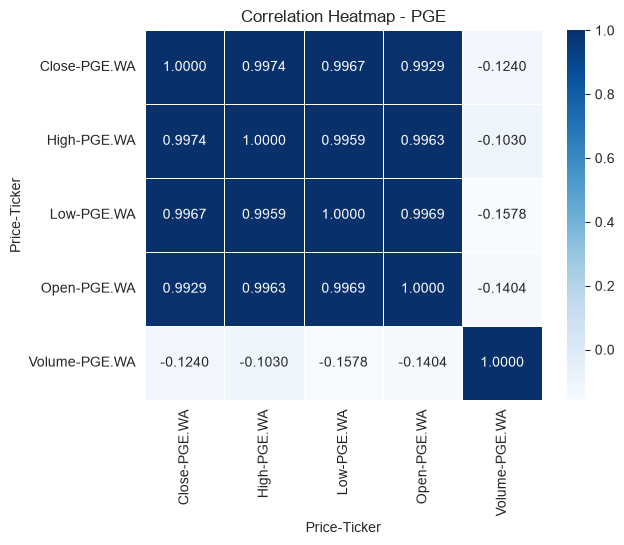

In [26]:
sns.heatmap(
    m_cor,
    annot=True,
    cmap='Blues',
    fmt='.4f',
    linewidths=0.5,
)

plt.title('Correlation Heatmap - PGE')
plt.show()

corr(volume and close price) vs corr(log_return-volatility and volume) ???

In [27]:
volume = df['Volume']['PGE.WA']
volatility = log_returns.abs() #we use abstract

In [28]:
corr_data = pd.DataFrame({
    'volume': volume,
    'volatility': volatility,
}).dropna()

In [29]:
corr_pearson = corr_data['volume'].corr(corr_data['volatility'])
print(corr_pearson.round(2))

0.49


In [30]:
corr_sperman = corr_data['volume'].corr(corr_data['volatility'], method='spearman')
print(corr_sperman.round(2))

0.4


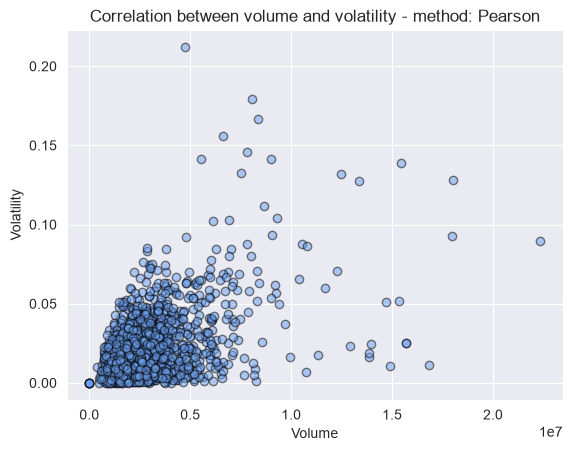

In [31]:
plt.scatter(
    corr_data['volume'],
    corr_data['volatility'],
    alpha=0.5,
    edgecolor='black',
    color='#6CA0EF',
)

plt.title('Correlation between volume and volatility - method: Pearson')
plt.xlabel('Volume')
plt.ylabel('Volatility')

plt.show()

In [32]:
corr_kendall = corr_data['volume'].corr(corr_data['volatility'], method='kendall')
print(corr_kendall.round(2))

0.28


In [33]:
a = st.linregress(corr_data['volume'], corr_data['volatility']).slope
b = st.linregress(corr_data['volume'], corr_data['volatility']).intercept
p_value = st.linregress(corr_data['volume'], corr_data['volatility']).pvalue
r_value = st.linregress(corr_data['volume'], corr_data['volatility']).rvalue #!!pearson corr (calculated above)
std_err = st.linregress(corr_data['volume'], corr_data['volatility']).stderr

trend_line = a * corr_data['volume'] + b #mathematical formula of regression: y = ax+b where "a" is slope and "b" is intercept in SciPy (alies - st)
print(f'p_value: {p_value:.4e} (p_value < 0.05)\nr_value: {r_value:.4e} (~{r_value:.4f})\nstd_err: {std_err:.4e}')

p_value: 5.8678e-91 (p_value < 0.05)
r_value: 4.8777e-01 (~0.4878)
std_err: 2.2313e-10


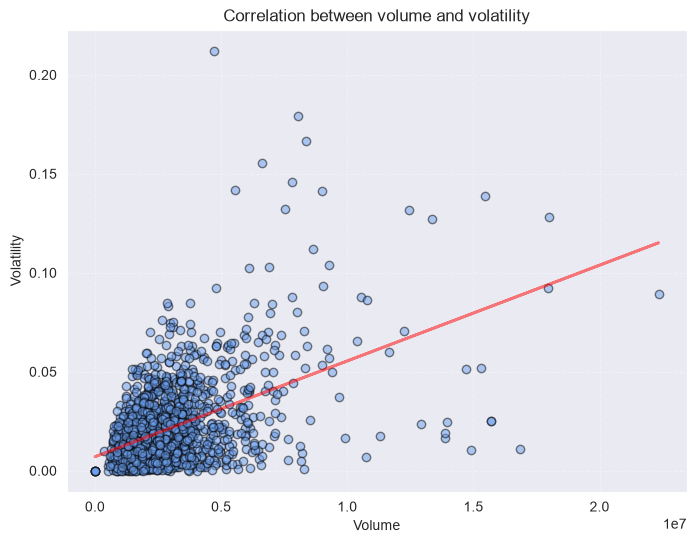

In [34]:
plt.figure(
    figsize(8, 6)
)

plt.scatter(
    corr_data['volume'],
    corr_data['volatility'],
    alpha=0.5,
    edgecolor='black',
    color='#6CA0EF',
)

plt.plot(
    corr_data['volume'],
    trend_line,
    alpha=0.5,
    color='red',
    linewidth=2,
    linestyle='-',
)

plt.grid(
    alpha = 0.3,
    linestyle = '--'
)

plt.title('Correlation between volume and volatility')
plt.xlabel('Volume')
plt.ylabel('Volatility')

plt.show()
#heteroscedasticity!!!!

#### INTERPRETATION
**(in progres)**

#### CORRELATION LOG-LOG

In [50]:
log_volume = df['Volume']['PGE.WA']
log_volume.replace(0, np.nan, inplace=True)
log_volume.dropna(inplace=True)
log_volume = np.log(log_volume)
log_volume

Date
2020-01-02    14.023773
2020-01-03    14.399683
2020-01-07    13.956866
2020-01-08    13.972698
2020-01-09    14.166272
                ...    
2025-12-19    15.911025
2025-12-22    14.839210
2025-12-23    14.467760
2025-12-29    14.229993
2025-12-30    14.709205
Name: PGE.WA, Length: 1502, dtype: float64

In [52]:
log_volatility = log_returns.abs()
log_volatility.replace(0, np.nan, inplace=True)
log_volatility.dropna(inplace=True)
log_volatility = np.log(log_volatility)
log_volatility

Date
2020-01-02   -3.277520
2020-01-03   -4.259256
2020-01-07   -3.598495
2020-01-08   -4.366901
2020-01-09   -5.971262
                ...   
2025-12-18   -3.247177
2025-12-19   -4.398737
2025-12-22   -4.811589
2025-12-29   -4.219495
2025-12-30   -5.497387
Name: PGE.WA, Length: 1487, dtype: float64

In [53]:
corr_data_log = pd.DataFrame({
    'log_volume': log_volume,
    'log_volatility': log_volatility,
})

corr_data_log

,log_volume,log_volatility
Date,,
2020-01-02,14.023773,-3.277520
2020-01-03,14.399683,-4.259256
2020-01-07,13.956866,-3.598495
2020-01-08,13.972698,-4.366901
2020-01-09,14.166272,-5.971262
...,...,...
2025-12-19,15.911025,-4.398737
2025-12-22,14.839210,-4.811589
2025-12-23,14.467760,NaN


#### Q-Q plot
*(in prgres)*

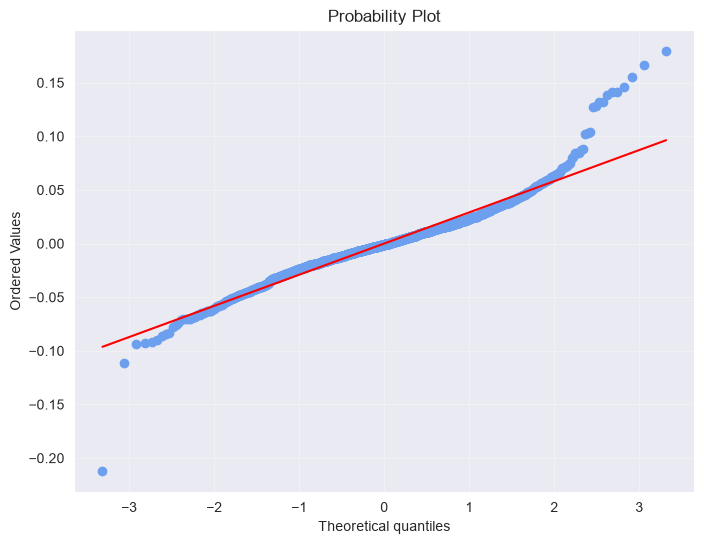

In [37]:
fig, ax = plt.subplots(figsize = (8, 6))
st.probplot(log_returns, plot=ax)

plt.grid(
    alpha = 0.3,
    linestyle = '-'
)

ax.get_lines()[0].set_color('#6CA0EF')
ax.get_lines()[1].set_color('red')

plt.show()